# Изучение структуры данных и первичный финансовый обзор

Этот ноутбук переписан так, чтобы брать данные из готовых итоговых таблиц проекта. Логика ориентируется на подход из `testing_data.ipynb`, но делает более аккуратный первый этап: понять, как устроены таблицы, как выглядят операции, категории, продажи, возвраты и как подготовиться к `Cash Flow` и `P&L`.

Что делаем:
- загружаем только готовые источники из папки `Итоговые таблицы`;
- описываем состав и качество таблиц;
- категоризируем банковские операции по назначению платежа;
- смотрим продажи, оплаты и возвраты;
- строим первые графики и формулируем выводы.

## Принцип работы

Исходные файлы не изменяются. Ноутбук только читает подготовленные таблицы и строит анализ поверх них.

In [ ]:
from pathlib import Path
import re

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

plt.style.use('seaborn-v0_8-whitegrid')
pd.set_option('display.max_columns', 100)
pd.set_option('display.max_colwidth', 140)
pd.set_option('display.float_format', lambda value: f'{value:,.2f}')


In [ ]:
def locate_data_root() -> Path:
    candidates = [Path.cwd(), *Path.cwd().parents]
    for base in candidates:
        target = (base / '..' / 'Курсач' / 'sladkiy_gorodok' / 'Данные' / 'Итоговые таблицы').resolve()
        if target.exists():
            return target
        target = (base / 'Курсач' / 'sladkiy_gorodok' / 'Данные' / 'Итоговые таблицы').resolve()
        if target.exists():
            return target
    raise FileNotFoundError('Не удалось найти папку Данные/Итоговые таблицы рядом с проектом.')


DATA_ROOT = locate_data_root()
DATA_ROOT


PosixPath('/Users/pavelesipenok/Documents/Курсач/sladkiy_gorodok/Данные/Итоговые таблицы')

In [ ]:
BANK_PATH = DATA_ROOT / 'bank_statement_transactions.csv'
SALES_PATH = DATA_ROOT / 'sales_by_counterparties.csv'
PAYMENTS_PATH = DATA_ROOT / 'sales_by_payment_counterparties.csv'

sources = pd.DataFrame(
    {
        'dataset': ['bank_statement_transactions', 'sales_by_counterparties', 'sales_by_payment_counterparties'],
        'path': [BANK_PATH, SALES_PATH, PAYMENTS_PATH],
        'exists': [BANK_PATH.exists(), SALES_PATH.exists(), PAYMENTS_PATH.exists()],
    }
)
sources


,dataset,path,exists
0,bank_statement_transactions,/Users/pavelesipenok/Documents/Курсач/sladkiy_gorodok/Данные/Итоговые таблицы/bank_statement_transactions.csv,True
1,sales_by_counterparties,/Users/pavelesipenok/Documents/Курсач/sladkiy_gorodok/Данные/Итоговые таблицы/sales_by_counterparties.csv,True
2,sales_by_payment_counterparties,/Users/pavelesipenok/Documents/Курсач/sladkiy_gorodok/Данные/Итоговые таблицы/sales_by_payment_counterparties.csv,True


## Загрузка готовых таблиц

Используем готовые `csv`, чтобы не зависеть от промежуточных Excel-файлов и ручной подготовки.

In [ ]:
bank = pd.read_csv(BANK_PATH)
sales = pd.read_csv(SALES_PATH)
payments = pd.read_csv(PAYMENTS_PATH)

print('bank:', bank.shape)
print('sales:', sales.shape)
print('payments:', payments.shape)


bank: (8056, 20)
sales: (2763, 26)
payments: (3358, 21)


In [31]:
bank.head(100)


,operation_date,document_number,debit,credit,amount,direction,counterparty_name,counterparty_inn,counterparty_kpp,counterparty_account,counterparty_bik,counterparty_bank_name,payment_purpose,debtor_code,document_type,source_file,source_file_path,source_file_hash,source_sheet,source_row_number,counterparty_normalized,month,operation_category,abs_amount
0,2025-05-01,250341,"1,690.00",0.00,"-1,690.00",debit,"АО ""АЛЬФА-БАНК""",7728168971,NaN,47423810901690006942,44525593,"АО ""АЛЬФА-БАНК"" г Москва","Комиссия за обсл.счета за период с 01.04.25 по 30.04.25 по ПУ ""Активный бизнес"" Осн.тарифы Банка,НДС не облаг. ООО ""СЛАДКИЙ ГОРОДОК""",NaN,Платежное требование,Выписка_40702810101690000356_01.05.2025–30.04.2026.xlsx,Данные/Выписки и данные/Выписка_40702810101690000356_01.05.2025–30.04.2026.xlsx,4b76869776b0396f99416042e2ef48c62c74d63100f729374e86b291584bc8a1,Выписка по счёту,4098,"АО ""АЛЬФА-БАНК""",2025-05,Налоги и взносы,"1,690.00"
1,2025-05-05,1614,0.00,"16,857.60","16,857.60",credit,"ООО ""ТОРГСЕРВИС 71""",7106023201,"710,601,001.00",40702810966000007592,47003608,ТУЛЬСКОЕ ОТДЕЛЕНИЕ N8604 ПАО СБЕРБАНК г Тула,Оплата за товар согласно договору поставки № тс71/2025-6 от 20.11.2024 Тула Парковая 7а. Сумма 16857-60 В т.ч. НДС(10%) 1532-51,NaN,Платежное поручение,Выписка_40702810101690000356_01.05.2025–30.04.2026.xlsx,Данные/Выписки и данные/Выписка_40702810101690000356_01.05.2025–30.04.2026.xlsx,4b76869776b0396f99416042e2ef48c62c74d63100f729374e86b291584bc8a1,Выписка по счёту,4067,"ООО ""ТОРГСЕРВИС 71""",2025-05,Поступления от клиентов,"16,857.60"
2,2025-05-05,1822,0.00,"6,693.20","6,693.20",credit,"ООО ""ТОРГСЕРВИС 71""",7106023201,"713,001,001.00",40702810766000014950,47003608,ТУЛЬСКОЕ ОТДЕЛЕНИЕ N8604 ПАО СБЕРБАНК г Тула,Оплата за товар согласно договору поставки № тс71/2025-6 от 20.11.2024 Тула Скуратовская 100А. Сумма 6693-20 В т.ч. НДС(10%) 608-47,NaN,Платежное поручение,Выписка_40702810101690000356_01.05.2025–30.04.2026.xlsx,Данные/Выписки и данные/Выписка_40702810101690000356_01.05.2025–30.04.2026.xlsx,4b76869776b0396f99416042e2ef48c62c74d63100f729374e86b291584bc8a1,Выписка по счёту,4068,"ООО ""ТОРГСЕРВИС 71""",2025-05,Поступления от клиентов,"6,693.20"
3,2025-05-05,1877,0.00,"5,800.00","5,800.00",credit,"ООО ""ТОРГСЕРВИС 71"" p/c 40702810866000016175 ТУЛЬСКОЕ ОТДЕЛЕНИЕ N8604 ПАО СБЕРБАНК г.Тула",7106023201,"710,601,001.00",30302810020006005500,42748634,КАЛИНИНГРАДСКОЕ ОТДЕЛЕНИЕ N8626 ПАО СБЕРБАНК г Калининград,Оплата за товар согласно договору поставки № тс71/2025-6 от 20.11.2024 Алексин Тульская зд 141 к1. Сумма 5800-00 В т.ч. НДС(10%) 527-27,NaN,Платежное поручение,Выписка_40702810101690000356_01.05.2025–30.04.2026.xlsx,Данные/Выписки и данные/Выписка_40702810101690000356_01.05.2025–30.04.2026.xlsx,4b76869776b0396f99416042e2ef48c62c74d63100f729374e86b291584bc8a1,Выписка по счёту,4069,"ООО ""ТОРГСЕРВИС 71"" P/C 40702810866000016175 ТУЛЬСКОЕ ОТДЕЛЕНИЕ N8604 ПАО СБЕРБАНК Г.ТУЛА",2025-05,Поступления от клиентов,"5,800.00"
4,2025-05-05,1074,0.00,"1,400.00","1,400.00",credit,"ООО ""ТОРГСЕРВИС 150"" p/c 40702810140000078025 ПАО СБЕРБАНК г.Москва",9723095473,"772,301,001.00",30302810020006005500,42748634,КАЛИНИНГРАДСКОЕ ОТДЕЛЕНИЕ N8626 ПАО СБЕРБАНК г Калининград,Оплата за товар согласно договору поставки № ТС150/25-241ПМСК от 31.12.2024 Волоколамск Спасс Центральная стр12бСумма 1400-00В т.ч. НДС(...,NaN,Платежное поручение,Выписка_40702810101690000356_01.05.2025–30.04.2026.xlsx,Данные/Выписки и данные/Выписка_40702810101690000356_01.05.2025–30.04.2026.xlsx,4b76869776b0396f99416042e2ef48c62c74d63100f729374e86b291584bc8a1,Выписка по счёту,4070,"ООО ""ТОРГСЕРВИС 150"" P/C 40702810140000078025 ПАО СБЕРБАНК Г.МОСКВА",2025-05,Поступления от клиентов,"1,400.00"
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
95,2025-05-14,2275,0.00,"16,857.80","16,857.80",credit,"ООО ""ТОРГСЕРВИС 71""",7106023201,"713,001,001.00",40702810766000016712,47003608,ТУЛЬСКОЕ ОТДЕЛЕНИЕ N8604 ПАО СБЕРБАНК г Тула

In [ ]:
sales.head(3)


,counterparty_raw,legal_entity,brand,store_location_raw,city_or_area,contract_raw,contract_number,contract_date,sales_doc_raw,sales_doc_type,sales_doc_number,sales_doc_date,sale_date,nomenclature,quantity,amount,period_label,period_start,period_end,source_file,source_file_path,source_file_hash,source_sheet,source_row_number,source_quantity_column,source_amount_column
0,"Торгсервис 150 ООО Магазин Светофор г. Руза, п. Дорохово, ул. Невкипелого, д. 4.А",Торгсервис 150 ООО,Светофор,"г. Руза, п. Дорохово, ул. Невкипелого, д. 4.А",г. Руза,ТС-150/24-008МО2 от 09.02.2024,ТС-150/24-008МО2,2024-02-09,Корректировка реализации № 235 от 06.05.2025,Корректировка реализации,235,2025-05-06,2025-05-06,"Сладости восточные ""Шакер-Чурек"" 1,0 кг",-70.00,"-14,000.00",Продажи по контрагентам за Май 2025 г. - Июнь 2025 г.,2025-05-01,2025-06-30,Продажи по контрагентам за Май 2025 г. - Июнь 2025 г..xls,Данные/Продажи по контрагентам/Продажи по контрагентам за Май 2025 г. - Июнь 2025 г..xls,475886a1077f89288781ddb2a6e07c338513d66c4589d72ef1a82227fa7663d2,Лист_1,462,06.05.25,NaN
1,"Торгсервис 150 ООО Магазин Светофор, г. Коломна, ул.Колхозная, д.8, стр.4",Торгсервис 150 ООО,Светофор,"г. Коломна, ул.Колхозная, д.8, стр.4",г. Коломна,ТС150/25-241 ПМСК от 31.12.2024,ТС150/25-241 ПМСК,2024-12-31,Корректировка реализации № 236 от 06.05.2025,Корректировка реализации,236,2025-05-06,2025-05-06,"Сладости восточные ""Шакер-Чурек"" 1,0 кг",-78.00,"-15,600.00",Продажи по контрагентам за Май 2025 г. - Июнь 2025 г.,2025-05-01,2025-06-30,Продажи по контрагентам за Май 2025 г. - Июнь 2025 г..xls,Данные/Продажи по контрагентам/Продажи по контрагентам за Май 2025 г. - Июнь 2025 г..xls,475886a1077f89288781ddb2a6e07c338513d66c4589d72ef1a82227fa7663d2,Лист_1,470,06.05.25,NaN
2,"Торгсервис 50 ООО Магазин Светофор г. Можайск, ул. Воинов-интернационалистов, д.12",Торгсервис 50 ООО,Светофор,"г. Можайск, ул. Воинов-интернационалистов, д.12",г. Можайск,ТС-50/24-008МО2 от 09.02.2024,ТС-50/24-008МО2,2024-02-09,Корректировка реализации № 239 от 06.05.2025,Корректировка реализации,239,2025-05-06,2025-05-06,"Сладости восточные ""Шакер-Чурек"" 1,0 кг",-138.00,"-27,600.00",Продажи по контрагентам за Май 2025 г. - Июнь 2025 г.,2025-05-01,2025-06-30,Продажи по контрагентам за Май 2025 г. - Июнь 2025 г..xls,Данные/Продажи по контрагентам/Продажи по контрагентам за Май 2025 г. - Июнь 2025 г..xls,475886a1077f89288781ddb2a6e07c338513d66c4589d72ef1a82227fa7663d2,Лист_1,593,06.05.25,NaN


In [ ]:
payments.head(3)


,period_label,period_start,period_end,counterparty_raw,legal_entity,brand,store_location_raw,city_or_area,contract_raw,contract_number,contract_date,payment_doc_raw,payment_doc_number,payment_date,amount,source_file,source_file_path,source_file_hash,source_sheet,source_row_number,source_column
0,Продажи по контрагентам (по оплате) за Май 2025 г. - Июнь 2025 г.,2025-05-01,2025-06-30,"Восторг 76 ООО Магазин Маяк, Подольск ул.Загородная д.1",Восторг 76 ООО,Маяк,Подольск ул.Загородная д.1,NaN,36/ВС от 20.09.2023,36/ВС,2023-09-20,Поступление на расчетный счет № 3538 от 05.05.2025,3538,2025-05-05,"6,644.00",Продажи по контрагентам (по оплате) за Май 2025 г. - Июнь 2025 г..xls,Данные/Продажи по контрагентам (по оплате)/Продажи по контрагентам (по оплате) за Май 2025 г. - Июнь 2025 г..xls,c843ae3d14f78c65d96e5dc16c0f169066d15037520408ecf71bcc39e97aa070,Лист_1,78,05.05.25
1,Продажи по контрагентам (по оплате) за Май 2025 г. - Июнь 2025 г.,2025-05-01,2025-06-30,"Восторг 76 ООО Магазин Маяк, Тульская обл., Ленинский р-н, п. Петровский, ул. Парковая , д.7",Восторг 76 ООО,Маяк,"Тульская обл., Ленинский р-н, п. Петровский, ул. Парковая , д.7",NaN,36/ВС от 20.09.2023,36/ВС,2023-09-20,Поступление на расчетный счет № 3718 от 05.05.2025,3718,2025-05-05,"8,496.00",Продажи по контрагентам (по оплате) за Май 2025 г. - Июнь 2025 г..xls,Данные/Продажи по контрагентам (по оплате)/Продажи по контрагентам (по оплате) за Май 2025 г. - Июнь 2025 г..xls,c843ae3d14f78c65d96e5dc16c0f169066d15037520408ecf71bcc39e97aa070,Лист_1,108,05.05.25
2,Продажи по контрагентам (по оплате) за Май 2025 г. - Июнь 2025 г.,2025-05-01,2025-06-30,"Восторг 76 ООО Магазин Маяк, г. Брянск, ул. 50-й Армии, стр.1Д",Восторг 76 ООО,Маяк,"г. Брянск, ул. 50-й Армии, стр.1Д",г. Брянск,36/ВС от 20.09.2023,36/ВС,2023-09-20,Поступление на расчетный счет № 3641 от 05.05.2025,3641,2025-05-05,"3,253.00",Продажи по контрагентам (по оплате) за Май 2025 г. - Июнь 2025 г..xls,Данные/Продажи по контрагентам (по оплате)/Продажи по контрагентам (по оплате) за Май 2025 г. - Июнь 2025 г..xls,c843ae3d14f78c65d96e5dc16c0f169066d15037520408ecf71bcc39e97aa070,Лист_1,156,05.05.25


## Вспомогательные функции

Нормализация нужна, чтобы по одним и тем же контрагентам и операциям можно было строить устойчивые срезы.

In [13]:
def clean_text(value):
    if pd.isna(value):
        return pd.NA
    text = str(value).strip()
    text = re.sub(r'\s+', ' ', text)
    return text if text else pd.NA


def normalize_counterparty(value):
    text = clean_text(value)
    if pd.isna(text):
        return pd.NA
    text = text.upper().replace('Ё', 'Е')
    text = re.sub(r'\bР/С\b.*$', '', text)
    text = re.sub(r'\bИНН\b.*$', '', text)
    text = re.sub(r'\s+', ' ', text).strip(' ,;')
    return text


def profile_table(df: pd.DataFrame, name: str) -> pd.DataFrame:
    return pd.DataFrame(
        {
            'dataset': name,
            'column': df.columns,
            'dtype': [str(dtype) for dtype in df.dtypes],
            'non_null': [int(df[col].notna().sum()) for col in df.columns],
            'nulls': [int(df[col].isna().sum()) for col in df.columns],
            'null_share': [df[col].isna().mean() for col in df.columns],
            'nunique': [int(df[col].nunique(dropna=True)) for col in df.columns],
        }
    ).sort_values(['null_share', 'nunique'], ascending=[False, True])


def categorize_bank_operation(purpose: str, counterparty: str, direction: str) -> str:
    text = ' '.join([part for part in [clean_text(purpose), clean_text(counterparty), clean_text(direction)] if not pd.isna(part)]).upper()
    rules = [
        ('Поступления от клиентов', ['ОПЛАТА ЗА ТОВАР', 'ПОСТУПЛЕНИЕ НА РАСЧЕТНЫЙ СЧЕТ', 'ОПЛАТА ПО ДОГОВОРУ ПОСТАВКИ']),
        ('Возвраты и корректировки', ['ВОЗВРАТ', 'КОРРЕКТИРОВ', 'СТОРНО']),
        ('Налоги и взносы', ['НАЛОГ', 'ЕНС', 'НДС', 'УСН', 'СТРАХОВ', 'СФР', 'ПФР', 'ФСС']),
        ('Зарплата и персонал', ['ЗАРАБОТН', 'ЗАРПЛАТ', 'АВАНС', 'ОТПУСК', 'ПОДОТЧЕТ', 'СОТРУДНИК']),
        ('Кредиты и проценты', ['КРЕДИТ', 'ПРОЦЕНТ', 'ОВЕРДРАФТ', 'ССУДА']),
        ('Комиссии банка', ['КОМИССИЯ', 'ОБСЛУЖИВАНИЕ СЧЕТА', 'ЭКВАЙРИНГ']),
        ('Логистика', ['ДОСТАВК', 'ЛОГИСТ', 'ПЕРЕВОЗК', 'ТРАНСПОРТ', 'ГСМ']),
        ('Аренда и коммунальные', ['АРЕНД', 'КОММУНАЛ', 'ЭЛЕКТРО', 'ГАЗ', 'ВОДА']),
        ('Сырье и закупки', ['СЫРЬ', 'МУКА', 'САХАР', 'МАТЕРИАЛ', 'ИНГРЕДИЕНТ', 'УПАКОВК', 'ПОСТАВЩИК']),
        ('Собственники и вывод средств', ['УЧРЕДИТЕЛ', 'ДИВИДЕНД', 'ВЫВОД', 'ЗАЙМ УЧРЕДИТЕЛ']),
    ]
    for category, patterns in rules:
        if any(pattern in text for pattern in patterns):
            return category
    return 'Прочее / требует разметки'


## Нормализация и подготовка

Приводим даты, суммы и текстовые поля к единому виду. На этом шаге создаем рабочие поля для анализа: месяц, нормализованный контрагент, признак продажи или возврата, категория операции.

In [14]:
bank = bank.copy()
bank['operation_date'] = pd.to_datetime(bank['operation_date'], errors='coerce')
bank['amount'] = pd.to_numeric(bank['amount'], errors='coerce')
bank['debit'] = pd.to_numeric(bank['debit'], errors='coerce')
bank['credit'] = pd.to_numeric(bank['credit'], errors='coerce')
bank['counterparty_name'] = bank['counterparty_name'].map(clean_text)
bank['payment_purpose'] = bank['payment_purpose'].map(clean_text)
bank['document_type'] = bank['document_type'].map(clean_text)
bank['counterparty_normalized'] = bank['counterparty_name'].map(normalize_counterparty)
bank['month'] = bank['operation_date'].dt.to_period('M').astype(str)
bank['operation_category'] = bank.apply(
    lambda row: categorize_bank_operation(row['payment_purpose'], row['counterparty_name'], row['direction']),
    axis=1,
)
bank['abs_amount'] = bank['amount'].abs()

sales = sales.copy()
for column in ['contract_date', 'sales_doc_date', 'sale_date', 'period_start', 'period_end']:
    sales[column] = pd.to_datetime(sales[column], errors='coerce')
sales['amount'] = pd.to_numeric(sales['amount'], errors='coerce')
sales['quantity'] = pd.to_numeric(sales['quantity'], errors='coerce')
sales['counterparty_raw'] = sales['counterparty_raw'].map(clean_text)
sales['legal_entity'] = sales['legal_entity'].map(clean_text)
sales['nomenclature'] = sales['nomenclature'].map(clean_text)
sales['counterparty_normalized'] = sales['counterparty_raw'].map(normalize_counterparty)
sales['month'] = sales['sale_date'].dt.to_period('M').astype(str)
sales['operation_sign'] = np.where(sales['amount'] >= 0, 'sale', 'return_or_adjustment')

payments = payments.copy()
for column in ['period_start', 'period_end', 'contract_date', 'payment_date']:
    payments[column] = pd.to_datetime(payments[column], errors='coerce')
payments['amount'] = pd.to_numeric(payments['amount'], errors='coerce')
payments['counterparty_raw'] = payments['counterparty_raw'].map(clean_text)
payments['legal_entity'] = payments['legal_entity'].map(clean_text)
payments['payment_doc_raw'] = payments['payment_doc_raw'].map(clean_text)
payments['counterparty_normalized'] = payments['counterparty_raw'].map(normalize_counterparty)
payments['month'] = payments['payment_date'].dt.to_period('M').astype(str)

print('Подготовка завершена')


Подготовка завершена


## Паспорт таблиц

Здесь смотрим на заполненность и разнообразие полей. Это помогает заранее понять, где данные уже готовы для модели и отчетов, а где потребуется дополнительная ручная разметка.

In [15]:
profiles = pd.concat(
    [
        profile_table(bank, 'bank'),
        profile_table(sales, 'sales'),
        profile_table(payments, 'payments'),
    ],
    ignore_index=True,
)
profiles.head(40)


,dataset,column,dtype,non_null,nulls,null_share,nunique
0,bank,debtor_code,float64,0,8056,1.00,0
1,bank,counterparty_kpp,float64,7749,307,0.04,31
2,bank,source_sheet,object,8056,0,0.00,1
3,bank,direction,object,8056,0,0.00,2
4,bank,source_file,object,8056,0,0.00,2
5,bank,source_file_path,object,8056,0,0.00,2
6,bank,source_file_hash,object,8056,0,0.00,2
7,bank,document_type,object,8056,0,0.00,3
8,bank,operation_category,object,8056,0,0.00,6
9,bank,month,object,8056,0,0.00,13


In [16]:
print('Примеры банковских операций')
display(bank.sample(min(5, len(bank)), random_state=42)[['operation_date', 'direction', 'counterparty_name', 'payment_purpose', 'amount', 'operation_category']])

print('Примеры продаж')
display(sales.sample(min(5, len(sales)), random_state=42)[['sale_date', 'legal_entity', 'brand', 'nomenclature', 'quantity', 'amount', 'sales_doc_type']])

print('Примеры оплат')
display(payments.sample(min(5, len(payments)), random_state=42)[['payment_date', 'legal_entity', 'brand', 'amount', 'payment_doc_raw']])


Примеры банковских операций


,operation_date,direction,counterparty_name,payment_purpose,amount,operation_category
2748,2025-10-17,credit,"ООО ""ТОРГСЕРВИС 71"" Р/С 40702810866710000112 в ПАО Сбербанк г Москва",ОПЛАТА ЗА ТОВАР СОГЛАСНО ДОГОВОРУ ПОСТАВКИ № ТС71/2025-6 ОТ 20.11.2024 ОРЕЛ РОСТОВСКАЯ 13. СУММА 5714-70 В Т.Ч. НДС(10%) 519-52,"5,714.70",Поступления от клиентов
6273,2026-03-03,credit,"ООО ""ТОРГСЕРВИС 50"" Р/С 40702810040000066991 в ПАО Сбербанк г Москва",ОПЛАТА ЗА ТОВАР СОГЛАСНО ДОГОВОРУ ПОСТАВКИ № ТС50/25-241ПМСК ОТ 31.12.2024 МО ГО ДУБНА Г ДУБНА ПРД АВТОЛЮБИТЕЛЕЙ Д 6 СТР 1. СУММА 29337-...,"29,337.10",Поступления от клиентов
2034,2025-09-18,debit,"ООО ""МЕЛАНЖ""","Оплата по УПД № 1883 от 02.09.2025. за меланж пастеризованный, белок пастер. жидкий охлажденный. В том числе НДС 10%, 6590.91","-72,500.00",Налоги и взносы
5927,2026-02-18,credit,"ООО ""ВОСТОРГ 76"" Р/С 40702810077030022886 в ПАО Сбербанк г Москва","ОПЛАТА ЗА ТОВАР СОГЛАСНО ДОГОВОРУ ПОСТАВКИ № 36/ВС ОТ 20.09.2023 ВОРОНЕЖ МАРШАЛА ЖУКОВА 15СУММА 26944-20В Т.Ч. НДС(10%, 20%, 22%)","26,944.20",Поступления от клиентов
3340,2025-11-07,credit,"ООО ""ТОРГСЕРВИС 50"" Р/С 40702810240000066995 в ПАО Сбербанк г Москва",ОПЛАТА ЗА ТОВАР СОГЛАСНО ДОГОВОРУ ПОСТАВКИ № ТС50/25-241ПМСК ОТ 31.12.2024 ТАЛДОМ СОВЕТСКАЯ 13А. СУММА 12620-00 В Т.Ч. НДС(10%) 1147-27,"12,620.00",Поступления от клиентов


Примеры продаж


,sale_date,legal_entity,brand,nomenclature,quantity,amount,sales_doc_type
367,2025-07-22,Торгсервис 150 ООО,Светофор,"Изделия хлебобулочные маффин ""Каприз"" с изюмом 1,0 кг",200.00,"44,000.00",Реализация
1295,2025-11-04,Торгсервис 71 ООО,Светофор,"Изделия хлебобулочные""Мадлены "" ассорти с начинкой 1,0 кг",162.00,"33,647.40",Реализация
2209,2026-03-03,Торгсервис 50 ООО,Светофор,"Изделия хлебобулочные ""ЭТЮД "" с ванильной начинкой и изюмом 1,0 кг",80.00,"20,600.00",Реализация
2371,2026-03-17,Торгсервис 50 ООО,Светофор,"Изделия хлебобулочные ""ЭТЮД "" с ванильной начинкой и изюмом 1,0 кг",80.00,"20,600.00",Реализация
521,2025-08-08,Торгсервис 71 ООО,Светофор,"Изделия хлебобулочные""Мадлены "" ассорти с начинкой 1,0 кг",180.00,"37,386.00",Реализация


Примеры оплат


,payment_date,legal_entity,brand,amount,payment_doc_raw
1114,2025-10-10,Торгсервис 50 ООО,Светофор,"2,970.00",Поступление на расчетный счет № 3840 от 10.10.2025
1642,2025-11-21,Торгсервис 71 ООО,Светофор,"27,683.00",Поступление на расчетный счет № 4938 от 21.11.2025
1345,2025-10-27,Торгсервис 71 ООО,Светофор,"11,705.00",Поступление на расчетный счет № 3962 от 27.10.2025
1689,2025-11-24,Торгсервис 71 ООО,Светофор,"1,246.00",Поступление на расчетный счет № 2849 от 24.11.2025
196,2025-06-04,Торгсервис 71 ООО,Светофор,"10,626.00",Поступление на расчетный счет № 2357 от 04.06.2025


## Что представляют собой данные банка

Это база для будущего `Cash Flow`. Сейчас важно увидеть период, структуру дебета и кредита, частоту контрагентов и распределение категорий.

In [17]:
bank_summary = pd.Series(
    {
        'rows': len(bank),
        'period_start': bank['operation_date'].min(),
        'period_end': bank['operation_date'].max(),
        'total_inflow': bank.loc[bank['direction'] == 'credit', 'credit'].sum(),
        'total_outflow': bank.loc[bank['direction'] == 'debit', 'debit'].sum(),
        'net_cash_flow': bank['amount'].sum(),
        'unique_counterparties': bank['counterparty_normalized'].nunique(dropna=True),
        'uncategorized_share': (bank['operation_category'] == 'Прочее / требует разметки').mean(),
    }
)
bank_summary


rows                                    8056
period_start             2025-05-01 00:00:00
period_end               2026-05-08 00:00:00
total_inflow                   84,012,121.62
total_outflow                  84,143,807.71
net_cash_flow                    -131,686.09
unique_counterparties                     66
uncategorized_share                     0.00
dtype: object

In [18]:
bank['operation_category'].value_counts().to_frame('operations')


,operations
operation_category,
Поступления от клиентов,6640
Налоги и взносы,1344
Зарплата и персонал,64
Прочее / требует разметки,6
Возвраты и корректировки,1
Собственники и вывод средств,1


In [20]:
bank_category_flow = bank.groupby(['operation_category', 'direction'])['abs_amount'].sum().unstack(fill_value=0)
bank_category_flow = bank_category_flow.rename(columns={'credit': 'inflow', 'debit': 'outflow'}).sort_values('outflow', ascending=False)
bank_category_flow


direction,inflow,outflow
operation_category,,
Налоги и взносы,0.00,"82,047,865.71"
Прочее / требует разметки,0.00,"1,084,800.00"
Зарплата и персонал,0.00,"976,142.00"
Собственники и вывод средств,0.00,"35,000.00"
Возвраты и корректировки,"7,619.00",0.00
Поступления от клиентов,"84,004,502.62",0.00


In [21]:
bank_monthly = bank.groupby(['month', 'direction'])['abs_amount'].sum().unstack(fill_value=0).reset_index()
bank_monthly['net_cash_flow'] = bank_monthly.get('credit', 0) - bank_monthly.get('debit', 0)
bank_monthly


direction,month,credit,debit,net_cash_flow
0,2025-05,"978,948.80","1,070,650.02","-91,701.22"
1,2025-06,"2,290,230.04","1,997,094.08","293,135.96"
2,2025-07,"3,749,359.44","3,925,913.18","-176,553.74"
3,2025-08,"7,783,508.82","7,488,651.22","294,857.60"
4,2025-09,"7,204,124.52","7,726,104.84","-521,980.32"
5,2025-10,"11,536,219.64","11,230,405.22","305,814.42"
6,2025-11,"11,323,895.46","10,766,353.22","557,542.24"
7,2025-12,"10,293,925.20","10,644,308.96","-350,383.76"
8,2026-01,"5,318,882.40","5,028,366.30","290,516.10"
9,2026-02,"6,294,218.62","6,994,619.44","-700,400.82"


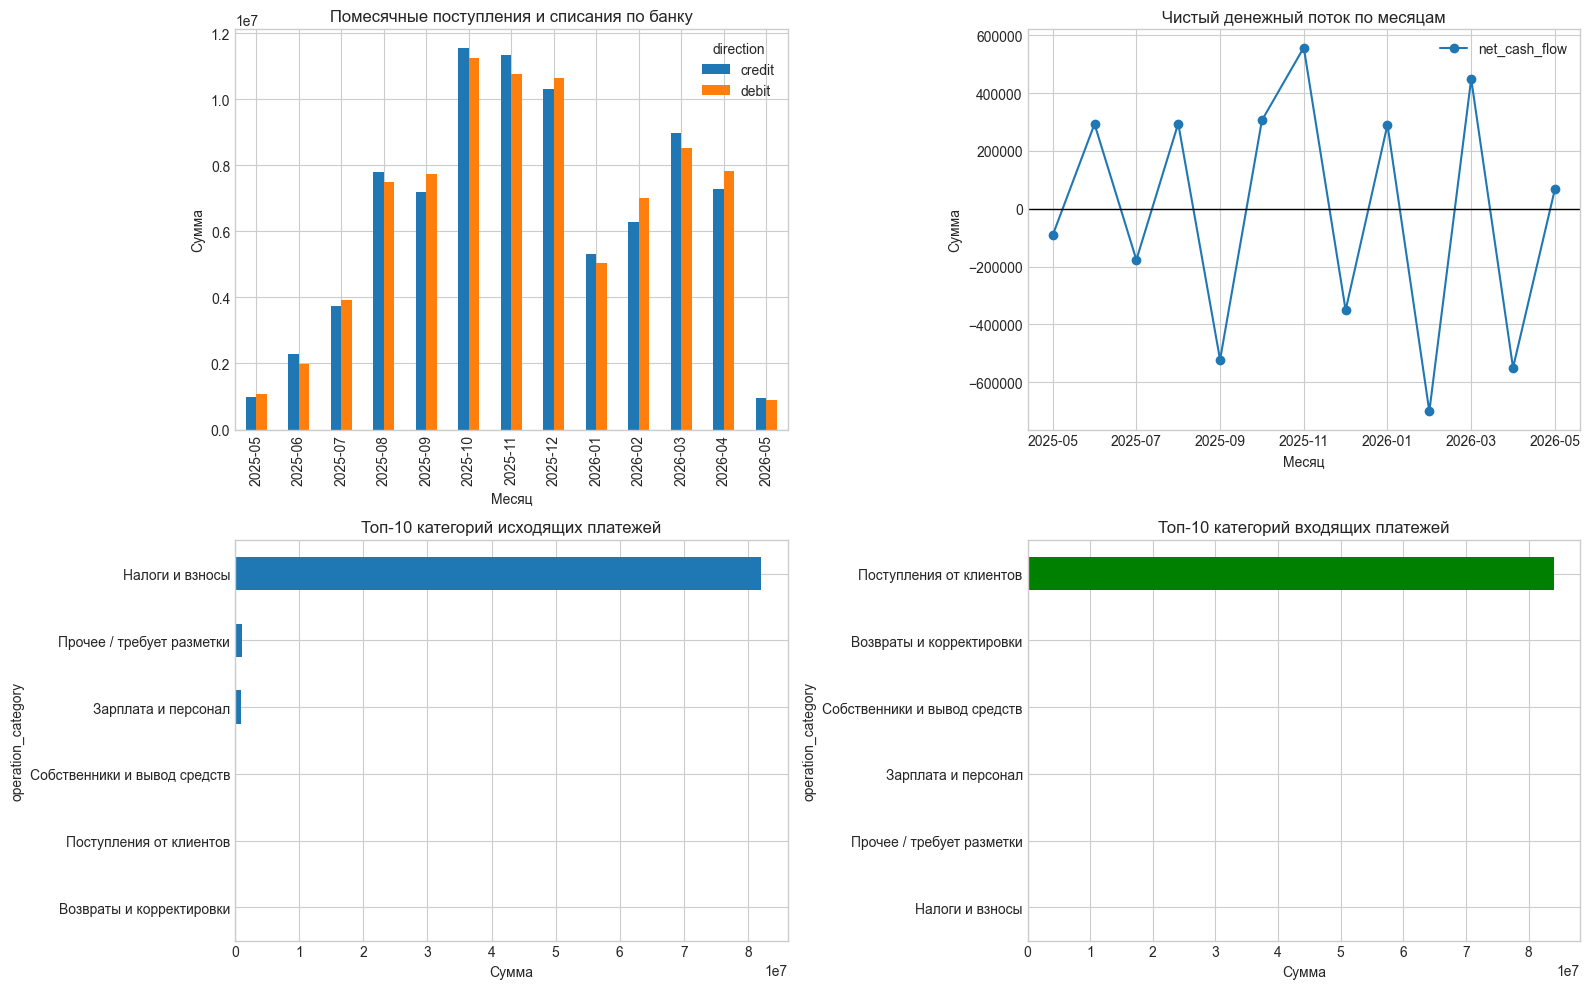

In [22]:
fig, axes = plt.subplots(2, 2, figsize=(16, 10))

bank_monthly.plot(x='month', y=['credit', 'debit'], kind='bar', ax=axes[0, 0], title='Помесячные поступления и списания по банку')
axes[0, 0].set_xlabel('Месяц')
axes[0, 0].set_ylabel('Сумма')

bank_monthly.plot(x='month', y='net_cash_flow', kind='line', marker='o', ax=axes[0, 1], title='Чистый денежный поток по месяцам')
axes[0, 1].axhline(0, color='black', linewidth=1)
axes[0, 1].set_xlabel('Месяц')
axes[0, 1].set_ylabel('Сумма')

bank_category_flow.sort_values('outflow', ascending=True).tail(10)['outflow'].plot(kind='barh', ax=axes[1, 0], title='Топ-10 категорий исходящих платежей')
axes[1, 0].set_xlabel('Сумма')

bank_category_flow.sort_values('inflow', ascending=True).tail(10)['inflow'].plot(kind='barh', ax=axes[1, 1], color='green', title='Топ-10 категорий входящих платежей')
axes[1, 1].set_xlabel('Сумма')

plt.tight_layout()


## Качество банковских данных и спорные операции

До построения ДДС полезно быстро увидеть потенциальные проблемы: пропуски, дубли, крупные платежи и операции, которые не попали в понятную категорию.

In [23]:
bank_issues = pd.Series(
    {
        'missing_date': int(bank['operation_date'].isna().sum()),
        'missing_counterparty': int(bank['counterparty_name'].isna().sum()),
        'missing_purpose': int(bank['payment_purpose'].isna().sum()),
        'duplicate_rows': int(bank.duplicated(subset=['operation_date', 'document_number', 'counterparty_name', 'amount']).sum()),
        'uncategorized_rows': int((bank['operation_category'] == 'Прочее / требует разметки').sum()),
    }
)
bank_issues


missing_date               0
missing_counterparty       0
missing_purpose            0
duplicate_rows          3866
uncategorized_rows         6
dtype: int64

In [24]:
large_ops_threshold = bank['abs_amount'].quantile(0.99)
bank.loc[
    bank['abs_amount'] >= large_ops_threshold,
    ['operation_date', 'direction', 'counterparty_name', 'payment_purpose', 'amount', 'operation_category']
].sort_values('amount').head(20)


,operation_date,direction,counterparty_name,payment_purpose,amount,operation_category
2837,2025-10-21,debit,"ООО ""РАДУГА Н""","Оплата по счету № 475 от 21.10.2025. за крем на растит маслах д/ взбивания, сумма 34980,00 в т. ч. ндс 20% 5830,00; молокосодержащий про...","-672,980.00",Налоги и взносы
2834,2025-10-21,debit,"ООО ""РАДУГА Н""","Оплата по счету № 475 от 21.10.2025. за крем на растит маслах д/ взбивания, сумма 34980,00 в т. ч. ндс 20% 5830,00; молокосодержащий про...","-672,980.00",Налоги и взносы
3815,2025-11-24,debit,"ООО ""РАДУГА Н""","Оплата по счету № 518 от 24.11.2025. за маргарин столовый, молокосодержащий продукт, сумма 275200-00. В том числе НДС 10%, 25018-18 руб....","-455,200.00",Налоги и взносы
3760,2025-11-24,debit,"ООО ""РАДУГА Н""","Оплата по счету № 518 от 24.11.2025. за маргарин столовый, молокосодержащий продукт, сумма 275200-00. В том числе НДС 10%, 25018-18 руб....","-455,200.00",Налоги и взносы
3819,2025-11-24,debit,"ООО ""РАДУГА Н""","Оплата по счету № 518 от 24.11.2025. за маргарин столовый, молокосодержащий продукт с сахаром со вкусом ""вареная сгущенка"". В том числе ...","-450,000.00",Налоги и взносы
2244,2025-09-30,debit,"ООО ""РАДУГА Н""","Оплата по счету № 445 от 30.09.2025. за заменитель молочного жира, сумма 213 000,00 в т. ч ндс 10% 19393,64 , начинку кондитерскую пасте...","-450,000.00",Налоги и взносы
2247,2025-09-30,debit,"ООО ""РАДУГА Н""","Оплата по счету № 445 от 30.09.2025. за заменитель молочного жира, сумма 213 000,00 в т. ч ндс 10% 19393,64 , начинку кондитерскую пасте...","-450,000.00",Налоги и взносы
3764,2025-11-24,debit,"ООО ""РАДУГА Н""","Оплата по счету № 518 от 24.11.2025. за маргарин столовый, молокосодержащий продукт с сахаром со вкусом ""вареная сгущенка"". В том числе ...","-450,000.00",Налоги и взносы
4535,2025-12-18,debit,"ООО ""РАДУГА Н""","Оплата по счету № 546 от 18.12.2025. за начинку кондит, ванилин, кокосовую стружку сумма 315200-00. В том числе НДС 20%, 52533-33 руб. ,...","-411,200.00",Налоги и взносы
4534,2025-12-18,debit,"ООО ""РАДУГА Н""","Оплата по счету № 546 от 18.12.2025. за начинку кондит, ванилин, кокосовую стружку сумма 315200-00. В том числе НДС 20%, 52533-33 руб. ,...","-411,200.00",Налоги и взносы


In [25]:
bank.loc[bank['operation_category'] == 'Прочее / требует разметки', ['operation_date', 'direction', 'counterparty_name', 'payment_purpose', 'amount']].head(20)


,operation_date,direction,counterparty_name,payment_purpose,amount
464,2025-06-20,debit,"ООО ""КОМПАНИЯ ""ТЕНЗОР""",Оплата по счету-оферте № 125052114092 от 21.05.2024.за право использования saby report корпаративный 5к,"-12,000.00"
479,2025-06-20,debit,"ООО ""КОМПАНИЯ ""ТЕНЗОР""",Оплата по счету-оферте № 125052114092 от 21.05.2024.за право использования saby report корпаративный 5к,"-12,000.00"
1984,2025-09-16,debit,"ООО ""РАДУГА Н""",Оплата по счету № 424 от 15.09.2025. за темную кондитерскую глазурь.,"-260,400.00"
1988,2025-09-16,debit,"ООО ""РАДУГА Н""",Оплата по счету № 424 от 15.09.2025. за темную кондитерскую глазурь.,"-260,400.00"
4908,2025-12-30,debit,"АО ""АЛЬФА-БАНК""",ПЕРЕВОД СР-В ПОД ОТЧЕТ НА ХОЗ.НУЖДЫ по //Реестру// от 30.12.2025 № 7100040031301225YUWQ к Договору ПДС от 23.06.2025 № SP-848194. Общее ...,"-270,000.00"
4936,2025-12-30,debit,"АО ""АЛЬФА-БАНК""",ПЕРЕВОД СР-В ПОД ОТЧЕТ НА ХОЗ.НУЖДЫ по //Реестру// от 30.12.2025 № 7100040031301225YUWQ к Договору ПДС от 23.06.2025 № SP-848194. Общее ...,"-270,000.00"


## Продажи и возвраты

Этот блок повторяет полезный фокус из `testing_data.ipynb`: понять динамику продаж и отдельно увидеть возвраты и корректировки, потому что они напрямую влияют на будущий `P&L`.

In [26]:
sales_summary = pd.Series(
    {
        'rows': len(sales),
        'period_start': sales['sale_date'].min(),
        'period_end': sales['sale_date'].max(),
        'gross_sales_amount': sales.loc[sales['amount'] > 0, 'amount'].sum(),
        'returns_amount': sales.loc[sales['amount'] < 0, 'amount'].sum(),
        'returns_share_abs': sales.loc[sales['amount'] < 0, 'amount'].abs().sum() / sales.loc[sales['amount'] > 0, 'amount'].sum(),
        'unique_products': sales['nomenclature'].nunique(dropna=True),
        'unique_counterparties': sales['counterparty_normalized'].nunique(dropna=True),
    }
)
sales_summary


rows                                    2763
period_start             2025-05-06 00:00:00
period_end               2026-04-30 00:00:00
gross_sales_amount             49,580,869.94
returns_amount                 -7,496,223.36
returns_share_abs                       0.15
unique_products                           15
unique_counterparties                    191
dtype: object

In [27]:
sales['sales_doc_type'].value_counts().to_frame('documents')


,documents
sales_doc_type,
Реализация,1952
Корректировка реализации,811


In [28]:
sales_monthly = sales.groupby(['month', 'operation_sign'])['amount'].sum().unstack(fill_value=0).reset_index()
sales_monthly['net_sales_amount'] = sales_monthly.get('sale', 0) + sales_monthly.get('return_or_adjustment', 0)
sales_monthly


operation_sign,month,return_or_adjustment,sale,net_sales_amount
0,2025-05,"-1,136,051.00","1,021,916.00","-114,135.00"
1,2025-06,"-633,261.00","2,274,957.00","1,641,696.00"
2,2025-07,"-246,600.00","4,232,569.00","3,985,969.00"
3,2025-08,"-715,560.00","4,120,009.00","3,404,449.00"
4,2025-09,"-625,840.00","5,299,088.00","4,673,248.00"
5,2025-10,"-221,333.23","6,999,511.70","6,778,178.47"
6,2025-11,"-298,600.07","5,543,321.72","5,244,721.65"
7,2025-12,"-447,940.82","4,534,850.52","4,086,909.70"
8,2026-01,"-542,489.05","2,041,419.00","1,498,929.95"
9,2026-02,"-412,150.39","4,701,630.00","4,289,479.61"


In [29]:
top_return_items = (
    sales.loc[sales['amount'] < 0]
    .groupby('nomenclature')[['quantity', 'amount']]
    .sum()
    .sort_values('amount')
    .head(15)
)
top_return_items


,quantity,amount
nomenclature,,
"Изделия хлебобулочные маффин ""Каприз"" с изюмом 1,0 кг","-13,711.00","-2,939,827.50"
"Изделия хлебобулочные""Мадлены "" ассорти с начинкой 1,0 кг","-5,180.00","-1,052,685.70"
"Сладости восточные ""Шакер-Чурек"" 1,0 кг","-3,912.00","-782,400.00"
"Сдобное хлебобулочное изделие ""ДИВНОЕ""с начинкой 1,0 кг","-2,976.00","-625,426.00"
"Изделия хлебобулочные ""Мечта"" 1,0 кг","-1,917.00","-383,400.00"
"Изделия хлебобулочные маффин ""Каприз"" 0,8 кг","-1,738.00","-347,600.00"
"Изделия хлебобулочные ""Улыбка "" песочное 1,0 кг","-1,552.00","-295,849.40"
"Изделия хлебобулочные ""Кокетка "" с ванильной начинкой и изюмом 1,0 кг","-1,177.00","-294,250.00"
"Изделия хлебобулочные ""МАЭСТРО"" песочное 1,0 кг","-1,274.00","-240,146.76"


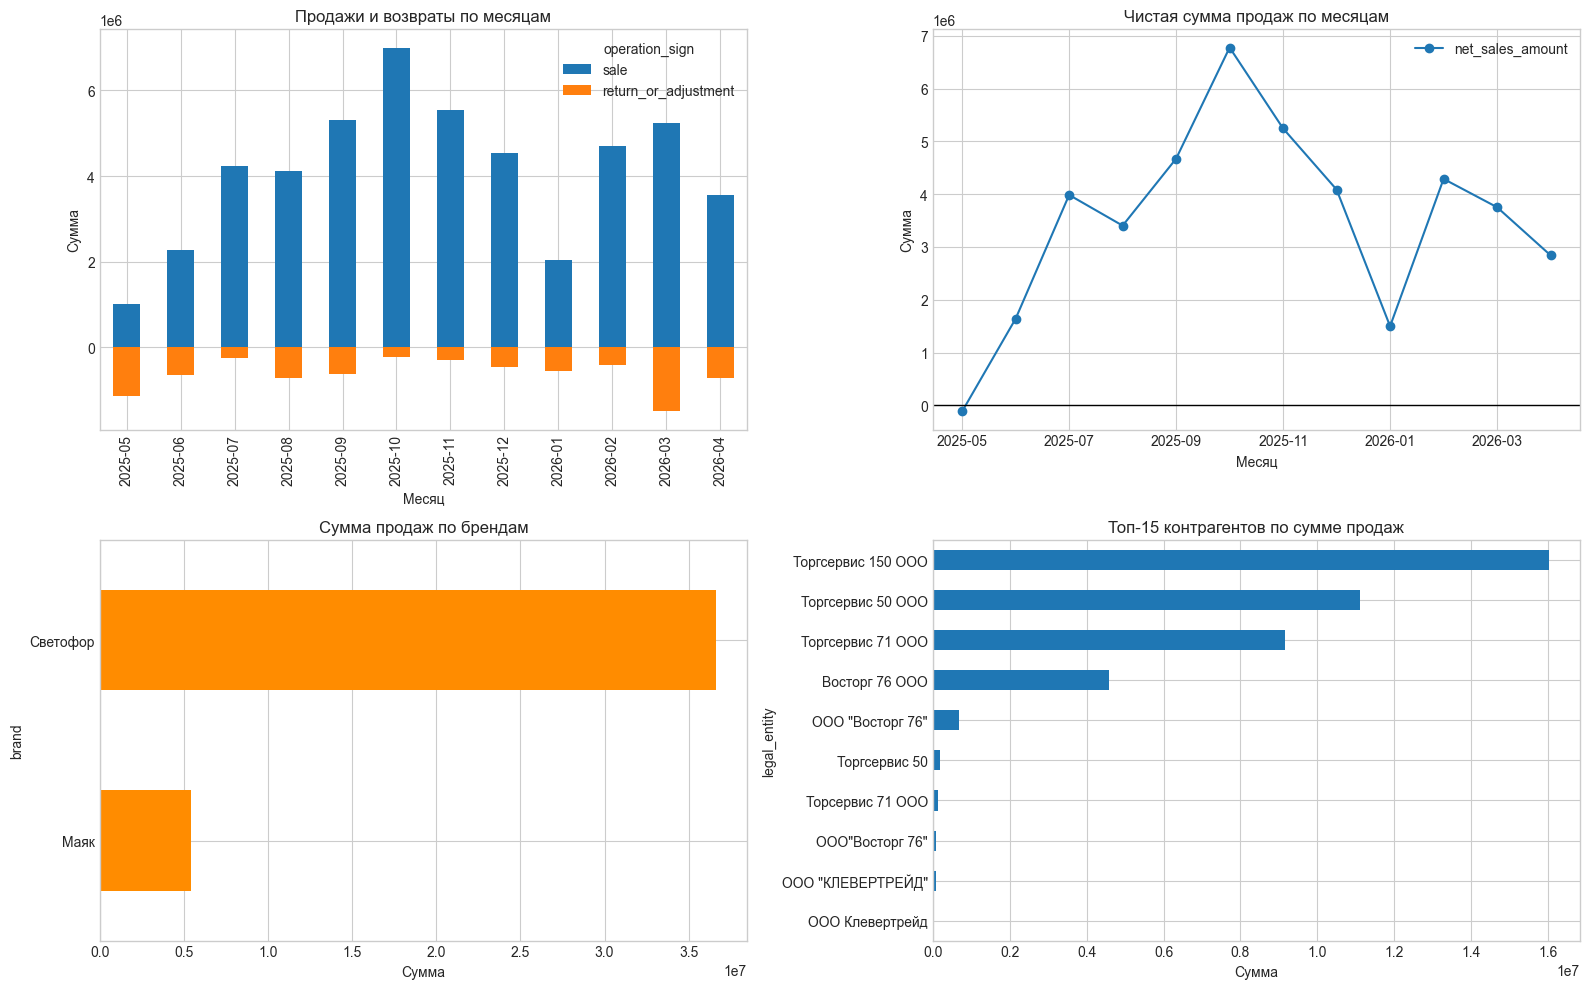

In [30]:
sales_by_brand = sales.groupby('brand', dropna=False)['amount'].sum().sort_values(ascending=False)
sales_by_counterparty = sales.groupby('legal_entity', dropna=False)['amount'].sum().sort_values(ascending=False).head(15)

fig, axes = plt.subplots(2, 2, figsize=(16, 10))

sales_monthly.plot(x='month', y=['sale', 'return_or_adjustment'], kind='bar', stacked=True, ax=axes[0, 0], title='Продажи и возвраты по месяцам')
axes[0, 0].set_xlabel('Месяц')
axes[0, 0].set_ylabel('Сумма')

sales_monthly.plot(x='month', y='net_sales_amount', kind='line', marker='o', ax=axes[0, 1], title='Чистая сумма продаж по месяцам')
axes[0, 1].axhline(0, color='black', linewidth=1)
axes[0, 1].set_xlabel('Месяц')
axes[0, 1].set_ylabel('Сумма')

sales_by_brand.sort_values(ascending=True).plot(kind='barh', ax=axes[1, 0], color='darkorange', title='Сумма продаж по брендам')
axes[1, 0].set_xlabel('Сумма')

sales_by_counterparty.sort_values(ascending=True).plot(kind='barh', ax=axes[1, 1], title='Топ-15 контрагентов по сумме продаж')
axes[1, 1].set_xlabel('Сумма')

plt.tight_layout()


## Оплаты от клиентов

Отдельно изучаем таблицу оплат. Это промежуточный слой между отгрузками и реальными банковскими поступлениями.

In [ ]:
payments_summary = pd.Series(
    {
        'rows': len(payments),
        'period_start': payments['payment_date'].min(),
        'period_end': payments['payment_date'].max(),
        'total_payments_amount': payments['amount'].sum(),
        'unique_counterparties': payments['counterparty_normalized'].nunique(dropna=True),
        'unique_payment_documents': payments['payment_doc_raw'].nunique(dropna=True),
    }
)
payments_summary


In [ ]:
payments_monthly = payments.groupby('month')['amount'].sum().rename('payments_amount')
payments_by_brand = payments.groupby('brand', dropna=False)['amount'].sum().sort_values(ascending=False)

fig, axes = plt.subplots(1, 2, figsize=(15, 5))
payments_monthly.plot(kind='bar', ax=axes[0], title='Оплаты по месяцам')
axes[0].set_xlabel('Месяц')
axes[0].set_ylabel('Сумма')

payments_by_brand.sort_values(ascending=True).plot(kind='barh', ax=axes[1], title='Оплаты по брендам')
axes[1].set_xlabel('Сумма')

plt.tight_layout()


## Первый мост: продажи, оплаты, банковские поступления

Это еще не окончательное сопоставление для `P&L` и `Cash Flow`, но уже видно, как соотносятся три уровня: продажи по отгрузке, оплаты из промежуточной таблицы и реальные поступления на расчетный счет.

In [ ]:
bank_client_inflow = (
    bank.loc[bank['operation_category'] == 'Поступления от клиентов']
    .groupby('month')['credit']
    .sum()
    .rename('bank_client_inflow')
)
sales_monthly_total = sales.groupby('month')['amount'].sum().rename('sales_amount')

bridge = pd.concat([sales_monthly_total, payments_monthly, bank_client_inflow], axis=1).sort_index()
bridge['payments_minus_sales'] = bridge['payments_amount'] - bridge['sales_amount']
bridge['bank_minus_payments'] = bridge['bank_client_inflow'] - bridge['payments_amount']
bridge


In [ ]:
bridge[['sales_amount', 'payments_amount', 'bank_client_inflow']].plot(figsize=(14, 5), marker='o', title='Продажи, оплаты и банковские поступления по месяцам')
plt.xlabel('Месяц')
plt.ylabel('Сумма')
plt.tight_layout()


## Первичные выводы для следующего этапа

После выполнения ноутбука имеет смысл зафиксировать:

1. Какие категории банковских операций уже ловятся уверенно, а какие еще нужно разметить вручную.
2. В какие месяцы проседают продажи, оплаты или реальные поступления.
3. Насколько существенны возвраты и по каким позициям они концентрируются.
4. Насколько согласуются таблицы продаж, оплат и банка на уровне месяцев.
5. Какие статьи расходов уже видны в банке и какие еще потребуют дополнительного справочника категорий.

Следующий шаг после этого ноутбука: собрать рабочую классификацию банковских операций для полноценного `Cash Flow`, а затем перейти к помесячному `P&L` и анализу расхождений между прибылью и деньгами.